La forma normal de esta bifuraccion 
$$
\dot{x} = x^2 + y^2 + \alpha \\
\dot{y} = \beta - 2xy
$$

veamos como se comportan los puntos de equilibrio para los valores  de $\alpha \in \{ -1, 0, 1\}$ y $\beta \in \{-1, 0,1\}$


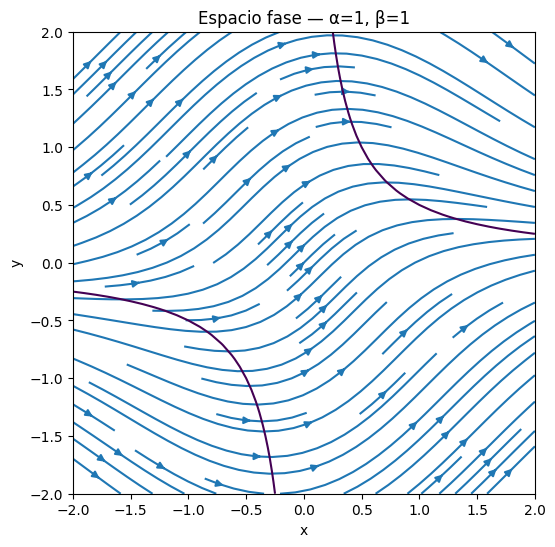

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math


fig = plt.figure(figsize=(6,6))
plt.streamplot(X, Y, U, V, density=1.0, arrowsize=1.0)

# Nulclinas
def safe_contour(Z, lvl=0.0):
    try:
        plt.contour(X, Y, Z, levels=[lvl])
    except Exception:
        pass

safe_contour(U, 0.0)
safe_contour(V, 0.0)

# Equilibrios (función auxiliar)
def equilibria(alpha, beta):
    eqs = []
    if alpha < 0:
        r = math.sqrt(-alpha)
        if abs(beta) < 1e-12:
            eqs = [( r, 0), (-r, 0), (0,  r), (0, -r)]
        else:
            xs = np.linspace(-r*1.5, r*1.5, 2000)
            xs = xs[np.abs(xs) > 1e-6]
            ys = (beta/2.0)/xs
            mask = np.abs(xs**2 + ys**2 - r**2) < 5e-3
            pts = np.column_stack([xs[mask], ys[mask]])
            for px, py in pts:
                if all((px - qx)**2 + (py - qy)**2 > 1e-3 for qx, qy in eqs):
                    eqs.append((float(px), float(py)))
            eqs = sorted(eqs)[:4]
    elif abs(alpha) < 1e-12 and abs(beta) < 1e-12:
        eqs = [(0.0, 0.0)]
    return eqs

eqs = equilibria(alpha, beta)
if eqs:
    ex, ey = zip(*eqs)
    plt.plot(ex, ey, 'o')

plt.title(f"Espacio fase — α={alpha}, β={beta}")
plt.xlabel("x"); plt.ylabel("y")
plt.xlim(-2,2); plt.ylim(-2,2)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Using matplotlib backend: widget


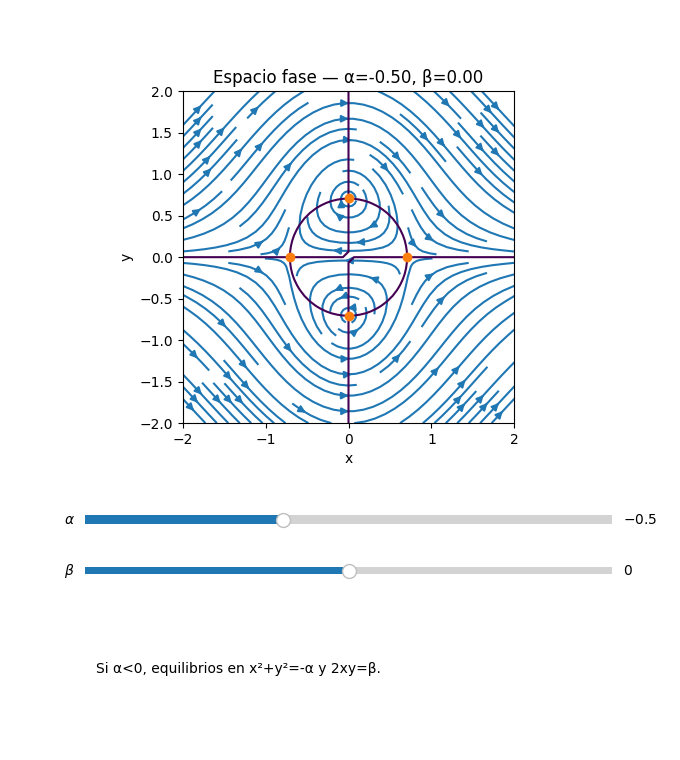

In [8]:
%matplotlib 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import math

# ----- Malla -----
x = np.linspace(-2, 2, 61)
y = np.linspace(-2, 2, 61)
X, Y = np.meshgrid(x, y)

# ----- Campo vectorial -----
def field(alpha, beta):
    U = X**2 + Y**2 + alpha
    V = beta - 2*X*Y
    return U, V

# ----- Utilidades (nulclinas y equilibrios) -----
def safe_contour(ax, Z, lvl=0.0):
    try:
        ax.contour(X, Y, Z, levels=[lvl])
    except Exception:
        pass

def equilibria(alpha, beta):
    """
    Para α < 0: x^2 + y^2 = -α y 2xy = β (intersección de nulclinas).
    Para α = β = 0: equilibrio en (0,0).
    """
    eqs = []
    if alpha < 0:
        r = math.sqrt(-alpha)
        if abs(beta) < 1e-12:
            eqs = [( r, 0), (-r, 0), (0,  r), (0, -r)]
        else:
            xs = np.linspace(-r*1.5, r*1.5, 4000)
            xs = xs[np.abs(xs) > 1e-8]
            ys = (beta/2.0)/xs
            mask = np.abs(xs**2 + ys**2 - r**2) < 5e-3
            pts = np.column_stack([xs[mask], ys[mask]])
            for px, py in pts:
                if all((px-qx)**2 + (py-qy)**2 > 1e-3 for qx, qy in eqs):
                    eqs.append((float(px), float(py)))
            eqs = sorted(eqs)[:4]
    elif abs(alpha) < 1e-12 and abs(beta) < 1e-12:
        eqs = [(0.0, 0.0)]
    return eqs

# ----- Figura y sliders -----
fig = plt.figure(figsize=(6.8, 7.6))
gs = fig.add_gridspec(nrows=6, ncols=1, height_ratios=[18, 1, 1, 0.8, 0.8, 0.8], hspace=0.5)

ax_plot = fig.add_subplot(gs[0, 0])
ax_alpha = fig.add_subplot(gs[2, 0])
ax_beta  = fig.add_subplot(gs[3, 0])
ax_text  = fig.add_subplot(gs[5, 0])
ax_text.axis("off")

alpha_slider = Slider(ax=ax_alpha, label=r'$\alpha$', valmin=-2.0, valmax=2.0, valinit=-0.5, valstep=0.01)
beta_slider  = Slider(ax=ax_beta,  label=r'$\beta$',  valmin=-2.0, valmax=2.0, valinit=0.0,  valstep=0.01)

def draw(alpha, beta):
    ax_plot.clear()
    U, V = field(alpha, beta)
    ax_plot.streamplot(X, Y, U, V, density=1.0, arrowsize=1.0)
    safe_contour(ax_plot, U, 0.0)  # ẋ = 0
    safe_contour(ax_plot, V, 0.0)  # ẏ = 0

    eq = equilibria(alpha, beta)
    if eq:
        ex, ey = zip(*eq)
        ax_plot.plot(ex, ey, 'o')

    ax_plot.set_title(f"Espacio fase — α={alpha:.2f}, β={beta:.2f}")
    ax_plot.set_xlabel("x"); ax_plot.set_ylabel("y")
    ax_plot.set_xlim(-2, 2); ax_plot.set_ylim(-2, 2)
    ax_plot.set_aspect('equal', adjustable='box')

    ax_text.clear(); ax_text.axis("off")
    if alpha < 0:
        ax_text.text(0.02, 0.5, "Si α<0, equilibrios en x²+y²=-α y 2xy=β.",
                     transform=ax_text.transAxes, fontsize=10, va="center")
    else:
        ax_text.text(0.02, 0.5, "Si α≥0, no hay equilibrios en ℝ² salvo α=β=0.",
                     transform=ax_text.transAxes, fontsize=10, va="center")

    fig.canvas.draw_idle()

def on_change(_):
    draw(alpha_slider.val, beta_slider.val)

alpha_slider.on_changed(on_change)
beta_slider.on_changed(on_change)

draw(alpha_slider.val, beta_slider.val)
plt.show()

